<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/economy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NeqSim-connected economy analysis for an NCS gas-field development

This notebook turns a thermodynamically consistent gas-processing model into a transparent
life-of-field economic screen. NeqSim calculates sales-gas flow, compression power, cooling
duty, mechanical design, and a process-package cost estimate. Python then builds the production,
cost, tax, discounting, break-even, and uncertainty calculations around those physical results.

The workbook is educational concept screening, not an investment recommendation, tax filing,
reserves report, or certified cost estimate. All monetary assumptions are explicit and synthetic.

## Intended audience, prerequisites, and learning objectives

The notebook is intended for students and early-phase field-development or process engineers.
Readers should understand steady-state separation and compression, annual cash flow, and basic
Python. No proprietary data or external files are required.

After completing the study, you should be able to:

1. build a composable NeqSim inlet-separation and export-compression process;
2. retrieve sales-gas flow, compressor power, cooler duty, and native cost-estimate results;
3. propagate declining production and inlet pressure through yearly process simulations;
4. calculate pre-tax and simplified after-tax cash flows, NPV, IRR, payback, and break-even price;
5. distinguish physical, commercial, fiscal, and estimate-basis assumptions;
6. test whether an economic conclusion is robust to price, CAPEX, OPEX, and discount rate.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim",
        ]
    )

import importlib.metadata
import math

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from neqsim import jneqsim

NEQSIM_VERSION = importlib.metadata.version("neqsim")
PYTHON_VERSION = sys.version.split()[0]
JAVA_VERSION = str(jpype.java.lang.System.getProperty("java.version"))

print(f"NeqSim: {NEQSIM_VERSION}")
print(f"Python: {PYTHON_VERSION}")
print(f"Java: {JAVA_VERSION}")

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.3f}".format

NeqSim: 3.16.0
Python: 3.12.13
Java: 17.0.19


## Decision scope and validity limits

The original page listed the main field-economics activities: resource evaluation, technical
feasibility, licensing, CAPEX, OPEX, decommissioning, price, taxation, financial metrics, risk,
environment, stakeholders, and scenarios. This expanded notebook preserves that intent but
implements a deliberately bounded calculation:

- a dry rich-gas feed is represented with the SRK equation of state and classic mixing rule;
- an inlet separator, export compressor, cooler, and pressure-control valve are connected;
- annual gas rate and inlet pressure are synthetic decline assumptions;
- the NeqSim cost estimator covers the demonstrated process package only;
- wells, SURF, host integration, drilling, project management, and owner costs are explicit
  external screening allowances;
- all cash flows are real, undiscounted NOK before the discounting calculation;
- no inflation, financing, working capital, hedging, tariff structure, or abandonment security
  is modeled.

Use this workflow to compare concepts consistently, then replace every screening assumption with
project-specific subsurface, facility, commercial, fiscal, and schedule data.

In [2]:
STUDY_BASIS = {
    "Production years": "2028-2042",
    "Availability": "94%",
    "Feed conditions": "40 degC; inlet pressure declines 70 to 30 bara",
    "Export pressure": "155 bara after the control valve",
    "Thermodynamic model": "SRK equation of state; classic mixing rule",
    "Compressor efficiency": "75% isentropic",
    "Gas price": "2.50 NOK/Sm3, constant real screening value",
    "Energy price": "0.65 NOK/kWh, constant real screening value",
    "Discount rate": "8% real",
    "Native cost currency": "USD; converted at illustrative 10.5 NOK/USD",
    "Fiscal model": "simplified symmetric 78% marginal cash-flow screen",
}

display(pd.Series(STUDY_BASIS, name="Value").to_frame())

                                                                   Value
Production years                                               2028-2042
Availability                                                         94%
Feed conditions           40 degC; inlet pressure declines 70 to 30 bara
Export pressure                         155 bara after the control valve
Thermodynamic model           SRK equation of state; classic mixing rule
Compressor efficiency                                     75% isentropic
Gas price                    2.50 NOK/Sm3, constant real screening value
Energy price                 0.65 NOK/kWh, constant real screening value
Discount rate                                                    8% real
Native cost currency         USD; converted at illustrative 10.5 NOK/USD
Fiscal model           simplified symmetric 78% marginal cash-flow sc...


## Governing economic equations

For cash flow $C_t$ in year $t$ and real discount rate $r$, the net present value is

$$
\mathrm{NPV} = \sum_{t=0}^{N} \frac{C_t}{(1+r)^t}
$$

The internal rate of return $r_{\mathrm{IRR}}$ satisfies

$$
0 = \sum_{t=0}^{N} \frac{C_t}{(1+r_{\mathrm{IRR}})^t}
$$

The break-even gas price is the price that makes NPV zero for the selected discount rate and all
other assumptions. NPV is an absolute value measure, while IRR and payback can be misleading when
cash flows change sign more than once. The notebook therefore retains the full annual cash-flow
table and does not rely on one metric alone.

## Thermodynamic and process equations

The separator imposes phase equilibrium. For component $i$ in phases $\alpha$ and $\beta$,

$$
f_i^{\alpha}(T,p,\mathbf{x}^{\alpha})
=
f_i^{\beta}(T,p,\mathbf{x}^{\beta})
$$

The process mass balance is

$$
\dot{m}_{\mathrm{feed}}
=
\dot{m}_{\mathrm{gas}}
+
\dot{m}_{\mathrm{liquid}}
$$

The compressor power is solved from the real-gas enthalpy change and specified isentropic
efficiency. The notebook reports power in MW and the cooler duty in MW. NeqSim uses a negative
cooler-duty sign when heat is removed from the process stream.

SRK is appropriate for this synthetic hydrocarbon-rich gas screening case. A water-rich,
glycol-rich, strongly associating, or acid-gas case may require CPA or another validated model.

## Fluid definition and composition audit

Mole fractions are normalized explicitly before the fluid is created. The composition is
synthetic and represents a methane-rich export-gas development. Pressure is absolute (`bara`);
flow in `MSm3/day` is standard volume, while equipment properties are evaluated at actual process
conditions.

In [3]:
FEED_COMPOSITION = {
    "nitrogen": 0.0100,
    "CO2": 0.0200,
    "methane": 0.8600,
    "ethane": 0.0600,
    "propane": 0.0250,
    "i-butane": 0.0100,
    "n-butane": 0.0100,
    "i-pentane": 0.0025,
    "n-pentane": 0.0025,
}

composition_sum = sum(FEED_COMPOSITION.values())
composition_table = (
    pd.Series(FEED_COMPOSITION, name="Mole fraction [-]")
    .rename_axis("Component")
    .to_frame()
)
composition_table["Composition [mol%]"] = (
    100.0 * composition_table["Mole fraction [-]"]
)

display(composition_table)
print(f"Composition sum: {composition_sum:.12f}")
assert abs(composition_sum - 1.0) < 1.0e-12

           Mole fraction [-]  Composition [mol%]
Component                                       
nitrogen               0.010               1.000
CO2                    0.020               2.000
methane                0.860              86.000
ethane                 0.060               6.000
propane                0.025               2.500
i-butane               0.010               1.000
n-butane               0.010               1.000
i-pentane              0.003               0.250
n-pentane              0.003               0.250
Composition sum: 1.000000000000


## How NeqSim represents the process

`SystemSrkEos` stores the fluid and thermodynamic model. `Stream` carries the fluid state and flow.
`Separator` performs the inlet flash, `Compressor` raises pressure, `Cooler` removes compression
heat, and `ThrottlingValve` defines the delivery pressure. `ProcessSystem` owns the connected
equipment and solves it in sequence.

The helper below returns every important object. This is more reusable than returning only a
table: a later notebook or digital twin can inspect, clone, optimize, or add constraints to the
same process objects.

In [4]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


def build_gas_process(
    rate_msm3_per_day,
    inlet_pressure_bara,
    export_pressure_bara=155.0,
):
    fluid = SystemSrkEos(313.15, float(inlet_pressure_bara))
    for component_name, mole_fraction in FEED_COMPOSITION.items():
        fluid.addComponent(component_name, float(mole_fraction))
    fluid.setMixingRule("classic")

    process = ProcessSystem()
    process.setName(
        f"Gas field at {rate_msm3_per_day:.3f} MSm3/day"
    )

    feed = Stream("Field inlet", fluid)
    feed.setFlowRate(float(rate_msm3_per_day), "MSm3/day")
    feed.setTemperature(40.0, "C")
    feed.setPressure(float(inlet_pressure_bara), "bara")

    separator = Separator("Inlet separator", feed)

    compressor = Compressor(
        "Export compressor",
        separator.getGasOutStream(),
    )
    compressor.setOutletPressure(160.0)
    compressor.setIsentropicEfficiency(0.75)

    cooler = Cooler(
        "Export cooler",
        compressor.getOutletStream(),
    )
    cooler.setOutTemperature(35.0, "C")

    export_valve = ThrottlingValve(
        "Export pressure control",
        cooler.getOutletStream(),
    )
    export_valve.setOutletPressure(float(export_pressure_bara))

    for unit in [feed, separator, compressor, cooler, export_valve]:
        process.add(unit)

    return {
        "process": process,
        "feed": feed,
        "separator": separator,
        "compressor": compressor,
        "cooler": cooler,
        "export_valve": export_valve,
    }

## Base-year process calculation

The base year produces 5.0 MSm3/day at 70 bara and exports at 155 bara. The compressor itself
discharges at 160 bara, leaving 5 bar for the pressure-control valve and downstream margin. The
mass residual and delivery pressure are checked before any economic calculation uses the result.

In [5]:
base_case = build_gas_process(
    rate_msm3_per_day=5.0,
    inlet_pressure_bara=70.0,
)
base_case["process"].run()

feed_mass_kg_per_h = float(
    base_case["feed"].getFlowRate("kg/hr")
)
gas_mass_kg_per_h = float(
    base_case["separator"].getGasOutStream().getFlowRate("kg/hr")
)
liquid_mass_kg_per_h = float(
    base_case["separator"].getLiquidOutStream().getFlowRate("kg/hr")
)
export_rate_msm3_per_day = float(
    base_case["export_valve"].getOutletStream().getFlowRate("MSm3/day")
)
export_pressure_bara = float(
    base_case["export_valve"].getOutletStream().getPressure("bara")
)
compressor_power_mw = float(
    base_case["compressor"].getPower("MW")
)
cooler_duty_mw = float(
    base_case["cooler"].getDuty()
) / 1.0e6
mass_residual = abs(
    feed_mass_kg_per_h
    - gas_mass_kg_per_h
    - liquid_mass_kg_per_h
) / feed_mass_kg_per_h

base_results = pd.Series(
    {
        "Feed mass flow [kg/h]": feed_mass_kg_per_h,
        "Separator gas flow [kg/h]": gas_mass_kg_per_h,
        "Separator liquid flow [kg/h]": liquid_mass_kg_per_h,
        "Export gas [MSm3/day]": export_rate_msm3_per_day,
        "Export pressure [bara]": export_pressure_bara,
        "Compressor power [MW]": compressor_power_mw,
        "Cooler duty [MW]": cooler_duty_mw,
        "Relative mass residual [-]": mass_residual,
    },
    name="Base year",
)
display(base_results.to_frame())

                               Base year
Feed mass flow [kg/h]        170,819.175
Separator gas flow [kg/h]    170,819.175
Separator liquid flow [kg/h]       0.000
Export gas [MSm3/day]              5.000
Export pressure [bara]           155.000
Compressor power [MW]              6.923
Cooler duty [MW]                 -11.754
Relative mass residual [-]         0.000


The base-case equipment results are the physical bridge to economics. Gas flow determines
revenue, compressor power determines annual energy cost, and process sizing supplies a native
equipment-cost screen. If the physical model changes, the economic result changes automatically.

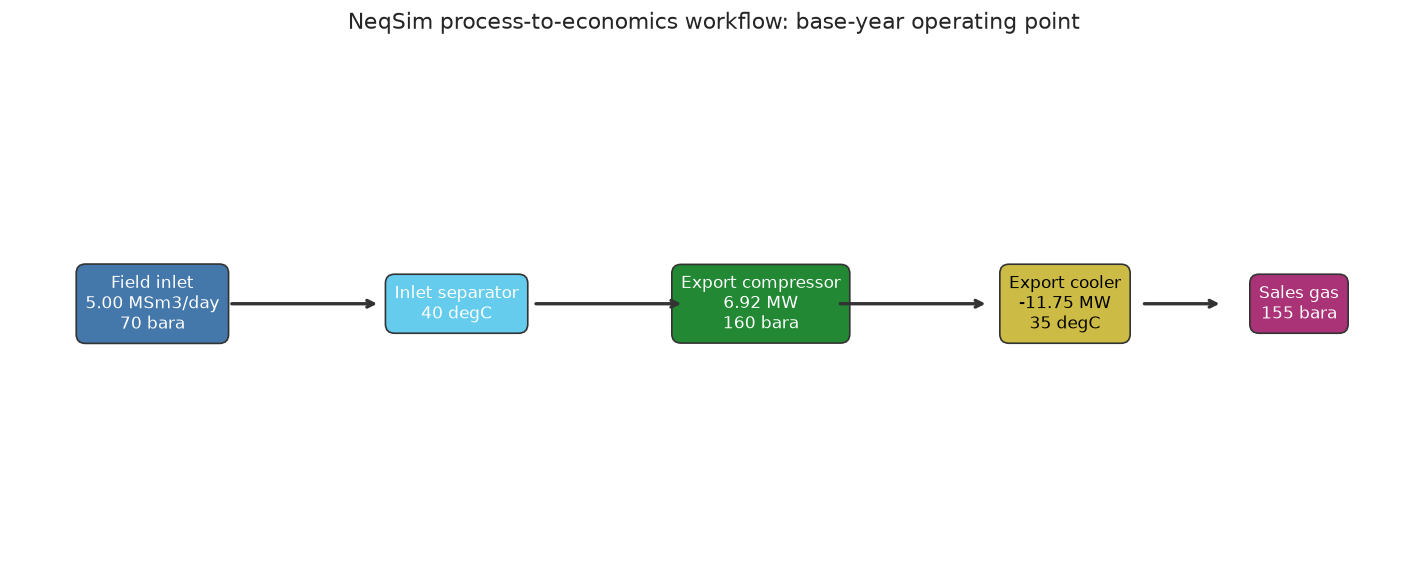

In [6]:
figure, axis = plt.subplots(figsize=(12.0, 4.8))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.0)
axis.axis("off")

equipment = [
    (1.2, "Field inlet\n5.00 MSm3/day\n70 bara"),
    (3.8, "Inlet separator\n40 degC"),
    (6.4, f"Export compressor\n{compressor_power_mw:.2f} MW\n160 bara"),
    (9.0, f"Export cooler\n{cooler_duty_mw:.2f} MW\n35 degC"),
    (11.0, "Sales gas\n155 bara"),
]
colors = ["#4477AA", "#66CCEE", "#228833", "#CCBB44", "#AA3377"]

for (x_position, label), color in zip(equipment, colors):
    axis.text(
        x_position,
        2.0,
        label,
        ha="center",
        va="center",
        fontsize=10,
        color="white" if color != "#CCBB44" else "black",
        bbox={
            "boxstyle": "round,pad=0.55",
            "facecolor": color,
            "edgecolor": "#333333",
        },
    )

for start, end in zip(equipment[:-1], equipment[1:]):
    axis.annotate(
        "",
        xy=(end[0] - 0.65, 2.0),
        xytext=(start[0] + 0.65, 2.0),
        arrowprops={"arrowstyle": "->", "color": "#333333", "lw": 2.0},
    )

axis.set_title(
    "NeqSim process-to-economics workflow: base-year operating point",
    fontsize=13,
    pad=16,
)
figure.tight_layout()
plt.show()

## Native mechanical design and process-package cost

NeqSim can initialize equipment mechanical design and aggregate a screening cost estimate. The
result below is used only for the demonstrated process package. It does **not** include reservoirs,
wells, subsea systems, host modifications, export pipelines, schedule risk, financing, or owner
costs. The illustrative NOK/USD conversion is an input, not a live exchange-rate claim.

This application complements the dedicated process-cost notebook: here the native estimate is one
input to a field cash-flow model rather than the final subject of the lesson.

In [7]:
base_case["process"].runMechanicalDesignAndCostEstimation()
mechanical_design = base_case["process"].getSystemMechanicalDesign()
native_cost = base_case["process"].getCostEstimate()
native_cost.setLocationByRegion("North Sea")
native_cost.calculateAllCosts()

USD_TO_NOK = 10.5
native_project_cost_usd = float(
    native_cost.getTotalProjectCost()
)
native_grass_roots_cost_usd = float(
    native_cost.getTotalGrassRootsCost()
)
native_purchased_cost_usd = float(
    native_cost.getTotalPurchasedEquipmentCost()
)
native_process_capex_nok = native_project_cost_usd * USD_TO_NOK

native_cost_table = pd.Series(
    {
        "Designed equipment count [-]": int(
            mechanical_design.getEquipmentList().size()
        ),
        "Estimated equipment weight [kg]": float(
            mechanical_design.getTotalWeight()
        ),
        "Purchased equipment cost [USD]": native_purchased_cost_usd,
        "Grass-roots cost [USD]": native_grass_roots_cost_usd,
        "Process project cost [USD]": native_project_cost_usd,
        "Illustrative conversion [NOK/USD]": USD_TO_NOK,
        "Converted process CAPEX [NOK]": native_process_capex_nok,
    },
    name="Native screening estimate",
)
display(native_cost_table.to_frame())

                                   Native screening estimate
Designed equipment count [-]                           5.000
Estimated equipment weight [kg]                   33,276.873
Purchased equipment cost [USD]                 2,562,412.068
Grass-roots cost [USD]                        15,166,676.802
Process project cost [USD]                    18,958,346.003
Illustrative conversion [NOK/USD]                     10.500
Converted process CAPEX [NOK]                199,062,633.028


# TAX

This heading and the tax teaching example are preserved from the original notebook. The numerical
logic is updated because the former use of 22% plus 56% as two direct taxes is no longer an
accurate representation of the post-2022 cash-flow system.

## Simplified Norwegian petroleum-tax screen

The Norwegian Tax Administration states that ordinary offshore income is taxed at 22%. Under the
cash-flow-based special petroleum tax, the technical special rate is 71.8%, and calculated company
tax is deducted from the special-tax base. This preserves a combined marginal rate close to 78%.

For a positive common profit basis $B$ in this simplified one-period illustration,

$$
T_{\mathrm{ordinary}} = 0.22 B
$$

$$
T_{\mathrm{special}} = 0.718
\left(B - T_{\mathrm{ordinary}}\right)
$$

The actual fiscal calculation has separate bases, investment deductions, depreciation, interest,
loss carry-forward or reimbursement, norm prices, and company-level consolidation. The project
cash-flow model later uses a symmetric 78% marginal approximation only to demonstrate sensitivity;
it is not a tax return or fiscal valuation.

The intentionally blank original Markdown cell is retained here as a preservation marker
between the tax overview and the numerical example.

## Preserved one-year Python tax example

The original example used NOK 100 million revenue and NOK 40 million deductible cost. We retain
those values but correct the special-tax calculation. The result demonstrates the rate algebra
only; it does not reproduce the different ordinary and special tax bases of a real company.

In [8]:
revenue = 100_000_000.0
costs = 40_000_000.0
ordinary_tax_rate = 0.22
technical_special_tax_rate = 0.718

taxable_income = max(revenue - costs, 0.0)
ordinary_tax = taxable_income * ordinary_tax_rate
special_tax_base = max(
    taxable_income - ordinary_tax,
    0.0,
)
special_petroleum_tax = (
    special_tax_base * technical_special_tax_rate
)
total_tax_liability = ordinary_tax + special_petroleum_tax
effective_tax_rate = total_tax_liability / taxable_income

tax_example = pd.Series(
    {
        "Revenue [NOK]": revenue,
        "Deductible costs [NOK]": costs,
        "Common illustrative basis [NOK]": taxable_income,
        "Ordinary tax [NOK]": ordinary_tax,
        "Special tax [NOK]": special_petroleum_tax,
        "Total tax [NOK]": total_tax_liability,
        "Effective rate [%]": 100.0 * effective_tax_rate,
    },
    name="Corrected one-year illustration",
)
display(tax_example.to_frame())

                                 Corrected one-year illustration
Revenue [NOK]                                    100,000,000.000
Deductible costs [NOK]                            40,000,000.000
Common illustrative basis [NOK]                   60,000,000.000
Ordinary tax [NOK]                                13,200,000.000
Special tax [NOK]                                 33,602,400.000
Total tax [NOK]                                   46,802,400.000
Effective rate [%]                                        78.004


## Reusable financial functions

The following functions keep metric definitions visible. Because decommissioning can introduce
more than one cash-flow sign change, the IRR helper scans a broad rate range, brackets every root,
and reports the lowest non-negative root. NPV remains the primary decision metric. Discounted
payback is the first fractional year in which cumulative discounted cash flow becomes non-negative.

In [9]:
def calculate_npv(cash_flows, discount_rate):
    cash_flow_array = np.asarray(cash_flows, dtype=float)
    periods = np.arange(cash_flow_array.size, dtype=float)
    discount_factors = (1.0 + float(discount_rate)) ** periods
    return float(np.sum(cash_flow_array / discount_factors))


def calculate_irr(cash_flows):
    rate_grid = np.concatenate(
        [
            np.linspace(-0.90, 0.0, 451, endpoint=False),
            np.linspace(0.0, 5.0, 2_501),
        ]
    )
    npv_grid = np.array(
        [calculate_npv(cash_flows, rate) for rate in rate_grid]
    )
    root_brackets = []

    for index in range(rate_grid.size - 1):
        if npv_grid[index] == 0.0:
            root_brackets.append(
                (rate_grid[index], rate_grid[index])
            )
        elif npv_grid[index] * npv_grid[index + 1] < 0.0:
            root_brackets.append(
                (rate_grid[index], rate_grid[index + 1])
            )

    roots = []
    for lower, upper in root_brackets:
        if lower == upper:
            roots.append(float(lower))
            continue

        lower_npv = calculate_npv(cash_flows, lower)
        for _ in range(120):
            midpoint = 0.5 * (lower + upper)
            midpoint_npv = calculate_npv(cash_flows, midpoint)
            if lower_npv * midpoint_npv <= 0.0:
                upper = midpoint
            else:
                lower = midpoint
                lower_npv = midpoint_npv
        roots.append(0.5 * (lower + upper))

    non_negative_roots = [root for root in roots if root >= 0.0]
    if not non_negative_roots:
        return math.nan
    return min(non_negative_roots)


def discounted_payback_year(cash_flows, discount_rate):
    cash_flow_array = np.asarray(cash_flows, dtype=float)
    periods = np.arange(cash_flow_array.size, dtype=float)
    discounted = cash_flow_array / (1.0 + discount_rate) ** periods
    cumulative = np.cumsum(discounted)

    crossing_indices = np.where(cumulative >= 0.0)[0]
    if crossing_indices.size == 0:
        return math.nan

    crossing = int(crossing_indices[0])
    if crossing == 0:
        return 0.0

    previous_balance = cumulative[crossing - 1]
    recovery_in_crossing_year = discounted[crossing]
    fraction = -previous_balance / recovery_in_crossing_year
    return float(crossing - 1 + fraction)

## Synthetic field-life schedule

Production begins after two development years. The field holds a 5.0 MSm3/day plateau for four
years, then declines by 12% per year. Inlet pressure falls linearly from 70 to 30 bara. Every
production year receives a fresh NeqSim process calculation; no power curve is imposed outside the
thermodynamic model.

In [10]:
PRODUCTION_YEARS = np.arange(2028, 2043)
production_index = np.arange(PRODUCTION_YEARS.size)
plateau_rate_msm3_per_day = 5.0
plateau_years = 4
annual_decline_fraction = 0.12

field_rate_msm3_per_day = np.where(
    production_index < plateau_years,
    plateau_rate_msm3_per_day,
    plateau_rate_msm3_per_day
    * (1.0 - annual_decline_fraction)
    ** (production_index - plateau_years + 1),
)
inlet_pressure_bara = np.linspace(
    70.0,
    30.0,
    PRODUCTION_YEARS.size,
)

schedule = pd.DataFrame(
    {
        "Year": PRODUCTION_YEARS,
        "Field rate [MSm3/day]": field_rate_msm3_per_day,
        "Inlet pressure [bara]": inlet_pressure_bara,
    }
)
display(schedule.head(8))

   Year  Field rate [MSm3/day]  Inlet pressure [bara]
0  2028                  5.000                 70.000
1  2029                  5.000                 67.143
2  2030                  5.000                 64.286
3  2031                  5.000                 61.429
4  2032                  4.400                 58.571
5  2033                  3.872                 55.714
6  2034                  3.407                 52.857
7  2035                  2.998                 50.000


## Execute the life-of-field NeqSim model

The loop configures the rate and inlet pressure, runs the full connected process, retrieves the
sales-gas rate, compressor power, cooler duty, and mass residual, and then discards the temporary
process. This pattern is directly reusable for reservoir forecasts or multiple uncertainty cases.

In [11]:
annual_process_rows = []

for year, rate, pressure in zip(
    PRODUCTION_YEARS,
    field_rate_msm3_per_day,
    inlet_pressure_bara,
):
    annual_case = build_gas_process(
        rate_msm3_per_day=rate,
        inlet_pressure_bara=pressure,
    )
    annual_case["process"].run()

    annual_feed_mass = float(
        annual_case["feed"].getFlowRate("kg/hr")
    )
    annual_gas_mass = float(
        annual_case["separator"].getGasOutStream().getFlowRate("kg/hr")
    )
    annual_liquid_mass = float(
        annual_case["separator"].getLiquidOutStream().getFlowRate("kg/hr")
    )
    annual_mass_residual = abs(
        annual_feed_mass
        - annual_gas_mass
        - annual_liquid_mass
    ) / annual_feed_mass

    annual_process_rows.append(
        {
            "Year": int(year),
            "Field rate [MSm3/day]": float(rate),
            "Inlet pressure [bara]": float(pressure),
            "Sales gas [MSm3/day]": float(
                annual_case["export_valve"]
                .getOutletStream()
                .getFlowRate("MSm3/day")
            ),
            "Compressor power [MW]": float(
                annual_case["compressor"].getPower("MW")
            ),
            "Cooler duty [MW]": float(
                annual_case["cooler"].getDuty()
            )
            / 1.0e6,
            "Mass residual [-]": annual_mass_residual,
        }
    )

annual_process = pd.DataFrame(annual_process_rows)
annual_process["Power intensity [kWh/Sm3]"] = (
    annual_process["Compressor power [MW]"]
    * 1_000.0
    * 24.0
    / (
        annual_process["Sales gas [MSm3/day]"]
        * 1.0e6
    )
)

display(annual_process)

    Year  Field rate [MSm3/day]  ...  Mass residual [-]  Power intensity [kWh/Sm3]
0   2028                  5.000  ...              0.000                      0.033
1   2029                  5.000  ...              0.000                      0.035
2   2030                  5.000  ...              0.000                      0.037
3   2031                  5.000  ...              0.000                      0.040
4   2032                  4.400  ...              0.000                      0.042
5   2033                  3.872  ...              0.000                      0.044
6   2034                  3.407  ...              0.000                      0.047
7   2035                  2.998  ...              0.000                      0.050
8   2036                  2.639  ...              0.000                      0.053
9   2037                  2.322  ...              0.000                      0.056
10  2038                  2.043  ...              0.000                      0.060
11  

The principal physical result should show two simultaneous effects: production declines,
but the pressure ratio increases. Total compressor power can fall with throughput while energy per
standard cubic metre rises. Economics must therefore use both production and power, not assume a
constant processing intensity.

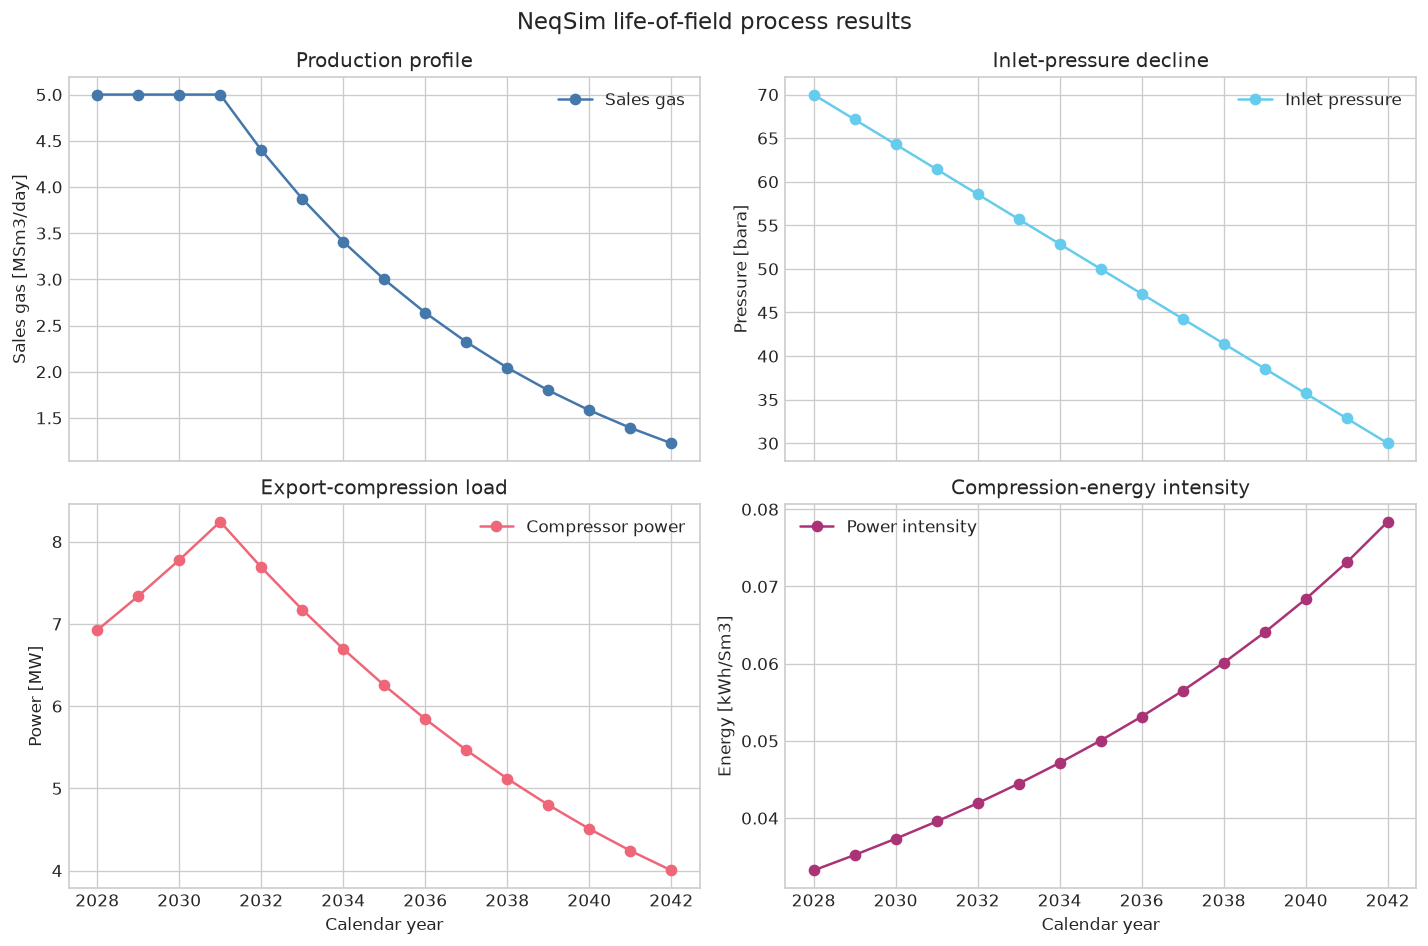

In [12]:
figure, axes = plt.subplots(2, 2, figsize=(12.0, 8.0), sharex=True)

axes[0, 0].plot(
    annual_process["Year"],
    annual_process["Sales gas [MSm3/day]"],
    marker="o",
    color="#4477AA",
    label="Sales gas",
)
axes[0, 0].set_ylabel("Sales gas [MSm3/day]")
axes[0, 0].set_title("Production profile")
axes[0, 0].legend()

axes[0, 1].plot(
    annual_process["Year"],
    annual_process["Inlet pressure [bara]"],
    marker="o",
    color="#66CCEE",
    label="Inlet pressure",
)
axes[0, 1].set_ylabel("Pressure [bara]")
axes[0, 1].set_title("Inlet-pressure decline")
axes[0, 1].legend()

axes[1, 0].plot(
    annual_process["Year"],
    annual_process["Compressor power [MW]"],
    marker="o",
    color="#EE6677",
    label="Compressor power",
)
axes[1, 0].set_ylabel("Power [MW]")
axes[1, 0].set_title("Export-compression load")
axes[1, 0].legend()

axes[1, 1].plot(
    annual_process["Year"],
    annual_process["Power intensity [kWh/Sm3]"],
    marker="o",
    color="#AA3377",
    label="Power intensity",
)
axes[1, 1].set_ylabel("Energy [kWh/Sm3]")
axes[1, 1].set_title("Compression-energy intensity")
axes[1, 1].legend()

for axis in axes[1, :]:
    axis.set_xlabel("Calendar year")

figure.suptitle(
    "NeqSim life-of-field process results",
    fontsize=14,
)
figure.tight_layout()
plt.show()

## Convert process results to annual cash flow

Annual standard gas volume is

$$
V_t
=
q_t A D
$$

where $q_t$ is sales-gas rate in Sm3/day, $A$ is availability, and $D$ is 365 day/year.
Electricity cost follows calculated compressor power:

$$
C_{\mathrm{energy},t}
=
P_t H A c_{\mathrm{energy}}
$$

where $P_t$ is kW, $H$ is 8760 h/year, and $c_{\mathrm{energy}}$ is NOK/kWh.

The field allowance adds wells, SURF, integration, and owner costs to the native process-package
estimate. CAPEX is split over 2026 and 2027, and decommissioning occurs in 2043.

In [13]:
AVAILABILITY = 0.94
GAS_PRICE_NOK_PER_SM3 = 2.50
ENERGY_PRICE_NOK_PER_KWH = 0.65
VARIABLE_OPEX_NOK_PER_SM3 = 0.08
FIXED_OPEX_NOK_PER_YEAR = 300.0e6
OTHER_FIELD_CAPEX_NOK = 9.0e9
DECOMMISSIONING_NOK = 1.5e9
DISCOUNT_RATE = 0.08

total_development_capex_nok = (
    native_process_capex_nok + OTHER_FIELD_CAPEX_NOK
)
combined_marginal_tax_rate = (
    ordinary_tax_rate
    + technical_special_tax_rate
    * (1.0 - ordinary_tax_rate)
)

cash_flow_years = np.arange(2026, 2044)
cash_flow = pd.DataFrame({"Year": cash_flow_years})
cash_flow["Sales gas [MSm3/day]"] = 0.0
cash_flow["Revenue [million NOK]"] = 0.0
cash_flow["Energy OPEX [million NOK]"] = 0.0
cash_flow["Other OPEX [million NOK]"] = 0.0
cash_flow["CAPEX [million NOK]"] = 0.0
cash_flow["Decommissioning [million NOK]"] = 0.0

cash_flow.loc[cash_flow["Year"] == 2026, "CAPEX [million NOK]"] = (
    0.45 * total_development_capex_nok / 1.0e6
)
cash_flow.loc[cash_flow["Year"] == 2027, "CAPEX [million NOK]"] = (
    0.55 * total_development_capex_nok / 1.0e6
)
cash_flow.loc[
    cash_flow["Year"] == 2043,
    "Decommissioning [million NOK]",
] = DECOMMISSIONING_NOK / 1.0e6

for process_row in annual_process.itertuples(index=False):
    year = int(process_row[0])
    sales_rate = float(process_row[3])
    compressor_power = float(process_row[4])
    annual_volume_sm3 = (
        sales_rate * 1.0e6 * 365.0 * AVAILABILITY
    )
    revenue_nok = annual_volume_sm3 * GAS_PRICE_NOK_PER_SM3
    energy_opex_nok = (
        compressor_power
        * 1_000.0
        * 8_760.0
        * AVAILABILITY
        * ENERGY_PRICE_NOK_PER_KWH
    )
    other_opex_nok = (
        FIXED_OPEX_NOK_PER_YEAR
        + annual_volume_sm3 * VARIABLE_OPEX_NOK_PER_SM3
    )

    row_mask = cash_flow["Year"] == year
    cash_flow.loc[row_mask, "Sales gas [MSm3/day]"] = sales_rate
    cash_flow.loc[row_mask, "Revenue [million NOK]"] = (
        revenue_nok / 1.0e6
    )
    cash_flow.loc[row_mask, "Energy OPEX [million NOK]"] = (
        energy_opex_nok / 1.0e6
    )
    cash_flow.loc[row_mask, "Other OPEX [million NOK]"] = (
        other_opex_nok / 1.0e6
    )

cash_flow["Pre-tax cash flow [million NOK]"] = (
    cash_flow["Revenue [million NOK]"]
    - cash_flow["Energy OPEX [million NOK]"]
    - cash_flow["Other OPEX [million NOK]"]
    - cash_flow["CAPEX [million NOK]"]
    - cash_flow["Decommissioning [million NOK]"]
)
cash_flow["Simplified tax [million NOK]"] = (
    combined_marginal_tax_rate
    * cash_flow["Pre-tax cash flow [million NOK]"]
)
cash_flow["After-tax cash flow [million NOK]"] = (
    cash_flow["Pre-tax cash flow [million NOK]"]
    - cash_flow["Simplified tax [million NOK]"]
)

display(cash_flow)

    Year  ...  After-tax cash flow [million NOK]
0   2026  ...                           -910.542
1   2027  ...                         -1,112.884
2   2028  ...                            839.027
3   2029  ...                            838.539
4   2030  ...                            838.022
5   2031  ...                            837.474
6   2032  ...                            728.546
7   2033  ...                            632.722
8   2034  ...                            548.426
9   2035  ...                            474.272
10  2036  ...                            409.039
11  2037  ...                            351.655
12  2038  ...                            301.175
13  2039  ...                            256.768
14  2040  ...                            217.702
15  2041  ...                            183.335
16  2042  ...                            153.100
17  2043  ...                           -329.940

[18 rows x 10 columns]


The negative tax rows in development and decommissioning years represent an immediate,
symmetric tax shield for a tax-paying company. A standalone project without taxable income may
realize deductions differently. Keep the pre-tax result and this simplified after-tax result side
by side; do not treat the latter as a fiscal-model substitute.

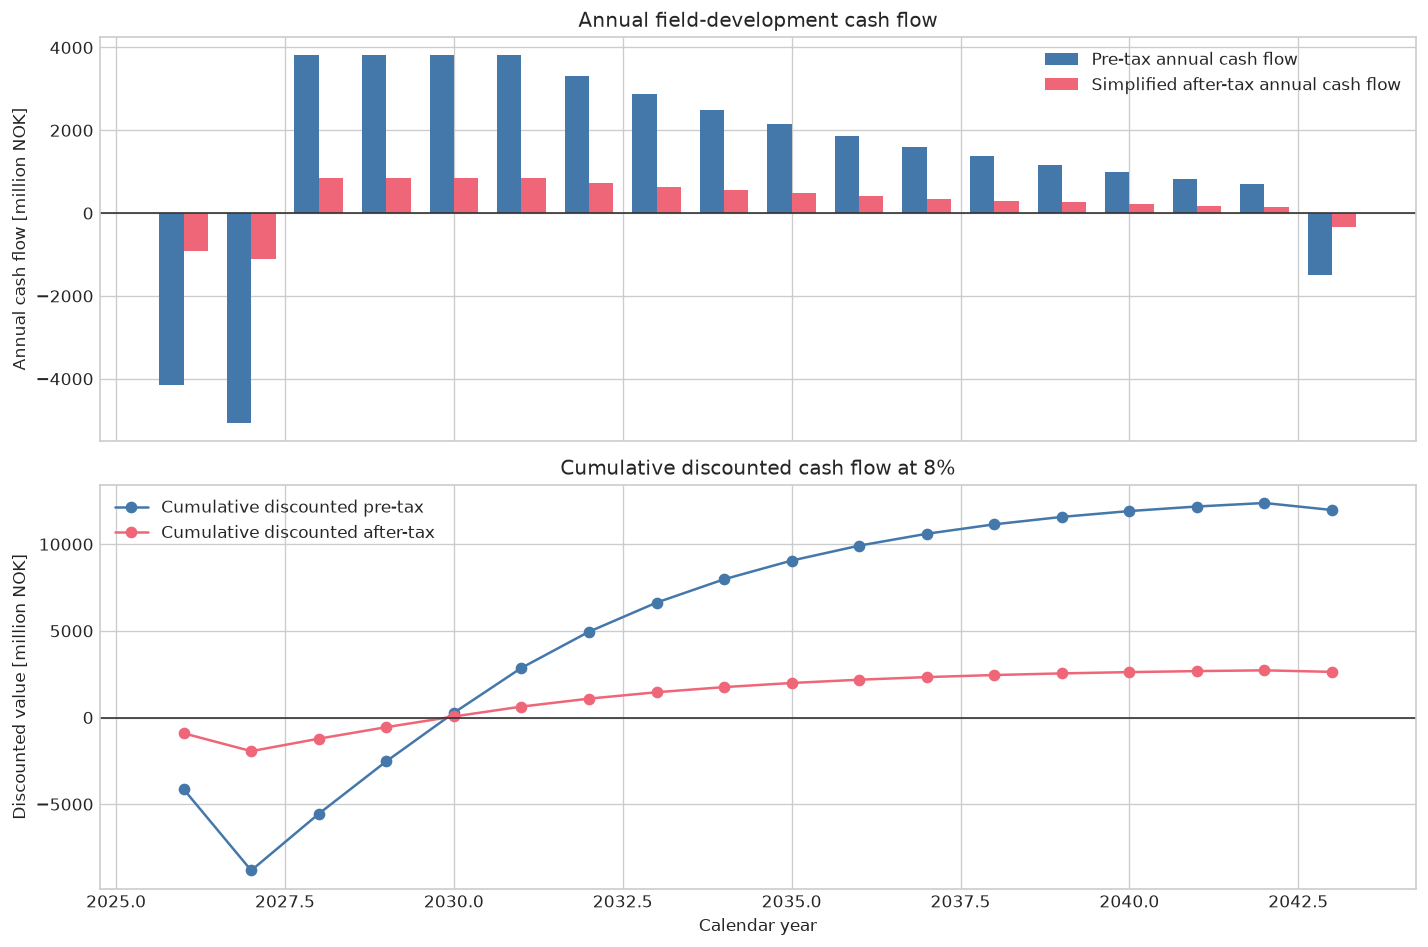

In [14]:
periods = np.arange(cash_flow.shape[0], dtype=float)
discount_factors = (1.0 + DISCOUNT_RATE) ** periods

cash_flow["Discounted pre-tax [million NOK]"] = (
    cash_flow["Pre-tax cash flow [million NOK]"]
    / discount_factors
)
cash_flow["Discounted after-tax [million NOK]"] = (
    cash_flow["After-tax cash flow [million NOK]"]
    / discount_factors
)
cash_flow["Cumulative discounted pre-tax [million NOK]"] = (
    cash_flow["Discounted pre-tax [million NOK]"].cumsum()
)
cash_flow["Cumulative discounted after-tax [million NOK]"] = (
    cash_flow["Discounted after-tax [million NOK]"].cumsum()
)

figure, axes = plt.subplots(2, 1, figsize=(12.0, 8.0), sharex=True)

axes[0].bar(
    cash_flow["Year"] - 0.18,
    cash_flow["Pre-tax cash flow [million NOK]"],
    width=0.36,
    color="#4477AA",
    label="Pre-tax annual cash flow",
)
axes[0].bar(
    cash_flow["Year"] + 0.18,
    cash_flow["After-tax cash flow [million NOK]"],
    width=0.36,
    color="#EE6677",
    label="Simplified after-tax annual cash flow",
)
axes[0].axhline(0.0, color="#333333", linewidth=1.0)
axes[0].set_ylabel("Annual cash flow [million NOK]")
axes[0].set_title("Annual field-development cash flow")
axes[0].legend()

axes[1].plot(
    cash_flow["Year"],
    cash_flow["Cumulative discounted pre-tax [million NOK]"],
    marker="o",
    color="#4477AA",
    label="Cumulative discounted pre-tax",
)
axes[1].plot(
    cash_flow["Year"],
    cash_flow["Cumulative discounted after-tax [million NOK]"],
    marker="o",
    color="#EE6677",
    label="Cumulative discounted after-tax",
)
axes[1].axhline(0.0, color="#333333", linewidth=1.0)
axes[1].set_xlabel("Calendar year")
axes[1].set_ylabel("Discounted value [million NOK]")
axes[1].set_title(f"Cumulative discounted cash flow at {DISCOUNT_RATE:.0%}")
axes[1].legend()

figure.tight_layout()
plt.show()

## Decision metrics and break-even price

The technical unit cost divides discounted costs by discounted sales volume. It is not a tariff or
accounting unit cost. The break-even price is solved by bisection against pre-tax NPV and uses the
same NeqSim-derived production and energy rows as the base case.

In [15]:
pre_tax_cash_flows = cash_flow[
    "Pre-tax cash flow [million NOK]"
].to_numpy()
after_tax_cash_flows = cash_flow[
    "After-tax cash flow [million NOK]"
].to_numpy()

pre_tax_npv_mnok = calculate_npv(
    pre_tax_cash_flows,
    DISCOUNT_RATE,
)
after_tax_npv_mnok = calculate_npv(
    after_tax_cash_flows,
    DISCOUNT_RATE,
)
pre_tax_irr = calculate_irr(pre_tax_cash_flows)
after_tax_irr = calculate_irr(after_tax_cash_flows)
discounted_payback = discounted_payback_year(
    pre_tax_cash_flows,
    DISCOUNT_RATE,
)

annual_sales_sm3 = (
    cash_flow["Sales gas [MSm3/day]"].to_numpy()
    * 1.0e6
    * 365.0
    * AVAILABILITY
)
discounted_sales_sm3 = float(
    np.sum(annual_sales_sm3 / discount_factors)
)
discounted_cost_mnok = float(
    np.sum(
        (
            cash_flow["Energy OPEX [million NOK]"]
            + cash_flow["Other OPEX [million NOK]"]
            + cash_flow["CAPEX [million NOK]"]
            + cash_flow["Decommissioning [million NOK]"]
        )
        / discount_factors
    )
)
technical_unit_cost_nok_per_sm3 = (
    discounted_cost_mnok * 1.0e6 / discounted_sales_sm3
)

metrics = pd.Series(
    {
        "Pre-tax NPV8 [million NOK]": pre_tax_npv_mnok,
        "Simplified after-tax NPV8 [million NOK]": after_tax_npv_mnok,
        "Pre-tax IRR [%]": 100.0 * pre_tax_irr,
        "Simplified after-tax IRR [%]": 100.0 * after_tax_irr,
        "Discounted pre-tax payback [years from 2026]": discounted_payback,
        "Discounted sales gas [billion Sm3]": discounted_sales_sm3 / 1.0e9,
        "Technical unit cost [NOK/Sm3]": technical_unit_cost_nok_per_sm3,
        "Total development CAPEX [million NOK]": (
            total_development_capex_nok / 1.0e6
        ),
    },
    name="Screening metric",
)
display(metrics.to_frame())

                                              Screening metric
Pre-tax NPV8 [million NOK]                          11,972.696
Simplified after-tax NPV8 [million NOK]              2,633.514
Pre-tax IRR [%]                                         31.396
Simplified after-tax IRR [%]                            31.396
Discounted pre-tax payback [years from 2026]             3.903
Discounted sales gas [billion Sm3]                       9.858
Technical unit cost [NOK/Sm3]                            1.286
Total development CAPEX [million NOK]                9,199.063


In [16]:
def pre_tax_npv_for_price(gas_price_nok_per_sm3):
    trial_cash_flow = pre_tax_cash_flows.copy()
    base_revenue = cash_flow["Revenue [million NOK]"].to_numpy()
    trial_revenue = (
        base_revenue
        * gas_price_nok_per_sm3
        / GAS_PRICE_NOK_PER_SM3
    )
    trial_cash_flow += trial_revenue - base_revenue
    return calculate_npv(trial_cash_flow, DISCOUNT_RATE)


lower_price = 0.0
upper_price = 10.0

for _ in range(120):
    midpoint_price = 0.5 * (lower_price + upper_price)
    midpoint_npv = pre_tax_npv_for_price(midpoint_price)
    if midpoint_npv > 0.0:
        upper_price = midpoint_price
    else:
        lower_price = midpoint_price

break_even_price_nok_per_sm3 = 0.5 * (
    lower_price + upper_price
)
break_even_npv_mnok = pre_tax_npv_for_price(
    break_even_price_nok_per_sm3
)

print(
    "Pre-tax break-even gas price: "
    f"{break_even_price_nok_per_sm3:.3f} NOK/Sm3"
)
print(
    "Residual NPV at solved price: "
    f"{break_even_npv_mnok:.6f} million NOK"
)

Pre-tax break-even gas price: 1.286 NOK/Sm3
Residual NPV at solved price: -0.000000 million NOK


## Gas-price and discount-rate sensitivity

The matrix recomputes pre-tax NPV without rerunning NeqSim because the physical production and
energy profile is unchanged. A change in inlet pressure, export pressure, composition, equipment,
or production rate would require a new process run. The chart separates commercial sensitivity
from physical sensitivity.

In [17]:
gas_prices = np.array([1.50, 2.00, 2.50, 3.00, 3.50])
discount_rates = np.array([0.06, 0.08, 0.10, 0.12])

sensitivity_rows = []
base_revenue_mnok = cash_flow["Revenue [million NOK]"].to_numpy()

for discount_rate in discount_rates:
    for gas_price in gas_prices:
        scenario_cash_flow = pre_tax_cash_flows.copy()
        scenario_revenue = (
            base_revenue_mnok
            * gas_price
            / GAS_PRICE_NOK_PER_SM3
        )
        scenario_cash_flow += scenario_revenue - base_revenue_mnok
        sensitivity_rows.append(
            {
                "Discount rate [%]": 100.0 * discount_rate,
                "Gas price [NOK/Sm3]": gas_price,
                "Pre-tax NPV [million NOK]": calculate_npv(
                    scenario_cash_flow,
                    discount_rate,
                ),
            }
        )

sensitivity_table = (
    pd.DataFrame(sensitivity_rows)
    .pivot(
        index="Discount rate [%]",
        columns="Gas price [NOK/Sm3]",
        values="Pre-tax NPV [million NOK]",
    )
)
display(sensitivity_table)

Gas price [NOK/Sm3]     1.500     2.000      2.500      3.000      3.500
Discount rate [%]                                                       
6.000               3,179.332 8,712.312 14,245.291 19,778.270 25,311.249
8.000               2,114.423 7,043.560 11,972.696 16,901.832 21,830.968
10.000              1,195.403 5,614.561 10,033.718 14,452.875 18,872.033
12.000                399.946 4,384.965  8,369.984 12,355.003 16,340.022


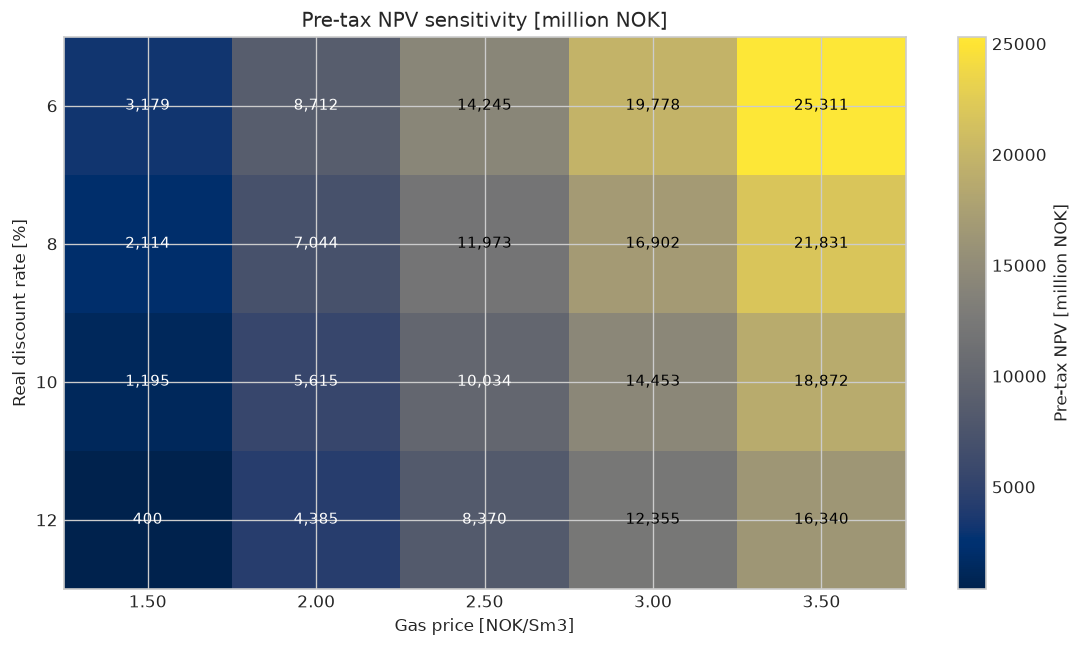

In [18]:
figure, axis = plt.subplots(figsize=(9.5, 5.5))
image = axis.imshow(
    sensitivity_table.to_numpy(),
    cmap="cividis",
    aspect="auto",
)

axis.set_xticks(np.arange(gas_prices.size))
axis.set_xticklabels([f"{value:.2f}" for value in gas_prices])
axis.set_yticks(np.arange(discount_rates.size))
axis.set_yticklabels(
    [f"{100.0 * value:.0f}" for value in discount_rates]
)
axis.set_xlabel("Gas price [NOK/Sm3]")
axis.set_ylabel("Real discount rate [%]")
axis.set_title("Pre-tax NPV sensitivity [million NOK]")

for row_index in range(sensitivity_table.shape[0]):
    for column_index in range(sensitivity_table.shape[1]):
        value = sensitivity_table.iloc[row_index, column_index]
        normalized_value = (
            value - sensitivity_table.to_numpy().min()
        ) / (
            sensitivity_table.to_numpy().max()
            - sensitivity_table.to_numpy().min()
        )
        axis.text(
            column_index,
            row_index,
            f"{value:,.0f}",
            ha="center",
            va="center",
            fontsize=9,
            color="white" if normalized_value < 0.45 else "black",
        )

colorbar = figure.colorbar(image, ax=axis)
colorbar.set_label("Pre-tax NPV [million NOK]")
figure.tight_layout()
plt.show()

## Tornado sensitivity at fixed physics

The tornado chart varies one commercial assumption at a time. Production variation scales the
already calculated NeqSim sales and power profiles together; it is a screening approximation.
A rigorous high/low production case should rerun the process because equipment efficiency,
phase split, bottlenecks, and pressure may change nonlinearly.

In [19]:
def scenario_npv(
    price_factor=1.0,
    capex_factor=1.0,
    opex_factor=1.0,
    energy_factor=1.0,
    production_factor=1.0,
):
    revenue = (
        cash_flow["Revenue [million NOK]"].to_numpy()
        * price_factor
        * production_factor
    )
    energy = (
        cash_flow["Energy OPEX [million NOK]"].to_numpy()
        * energy_factor
        * production_factor
    )
    other_opex = (
        cash_flow["Other OPEX [million NOK]"].to_numpy()
        * opex_factor
    )
    capex = (
        cash_flow["CAPEX [million NOK]"].to_numpy()
        * capex_factor
    )
    decommissioning = cash_flow[
        "Decommissioning [million NOK]"
    ].to_numpy()
    scenario_cash_flow = (
        revenue
        - energy
        - other_opex
        - capex
        - decommissioning
    )
    return calculate_npv(scenario_cash_flow, DISCOUNT_RATE)


tornado_cases = [
    ("Gas price +/-20%", {"price_factor": 0.8}, {"price_factor": 1.2}),
    ("Development CAPEX +/-20%", {"capex_factor": 1.2}, {"capex_factor": 0.8}),
    ("Other OPEX +/-20%", {"opex_factor": 1.2}, {"opex_factor": 0.8}),
    ("Energy price +/-20%", {"energy_factor": 1.2}, {"energy_factor": 0.8}),
    ("Production +/-10%", {"production_factor": 0.9}, {"production_factor": 1.1}),
]

tornado_rows = []
for label, low_arguments, high_arguments in tornado_cases:
    tornado_rows.append(
        {
            "Variable": label,
            "Low NPV [million NOK]": scenario_npv(**low_arguments),
            "High NPV [million NOK]": scenario_npv(**high_arguments),
        }
    )

tornado_table = pd.DataFrame(tornado_rows)
tornado_table["Range [million NOK]"] = (
    tornado_table["High NPV [million NOK]"]
    - tornado_table["Low NPV [million NOK]"]
).abs()
tornado_table = tornado_table.sort_values(
    "Range [million NOK]",
    ascending=True,
)
display(tornado_table)

                   Variable  ...  Range [million NOK]
3       Energy price +/-20%  ...              110.800
2         Other OPEX +/-20%  ...            1,266.518
1  Development CAPEX +/-20%  ...            3,529.714
4         Production +/-10%  ...            4,873.736
0          Gas price +/-20%  ...            9,858.272

[5 rows x 4 columns]


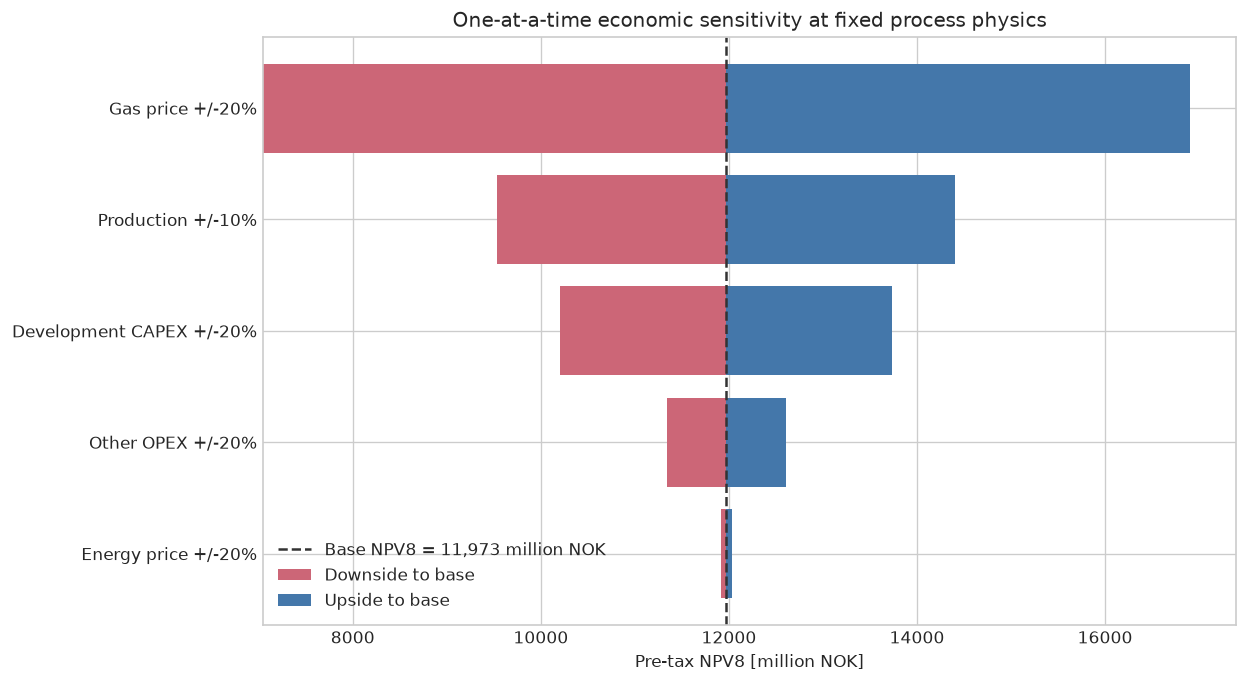

In [20]:
figure, axis = plt.subplots(figsize=(10.5, 5.8))
positions = np.arange(tornado_table.shape[0])
low_values = tornado_table["Low NPV [million NOK]"].to_numpy()
high_values = tornado_table["High NPV [million NOK]"].to_numpy()

axis.barh(
    positions,
    pre_tax_npv_mnok - low_values,
    left=low_values,
    color="#CC6677",
    label="Downside to base",
)
axis.barh(
    positions,
    high_values - pre_tax_npv_mnok,
    left=pre_tax_npv_mnok,
    color="#4477AA",
    label="Upside to base",
)
axis.axvline(
    pre_tax_npv_mnok,
    color="#333333",
    linestyle="--",
    linewidth=1.5,
    label=f"Base NPV8 = {pre_tax_npv_mnok:,.0f} million NOK",
)
axis.set_yticks(positions)
axis.set_yticklabels(tornado_table["Variable"])
axis.set_xlabel("Pre-tax NPV8 [million NOK]")
axis.set_title("One-at-a-time economic sensitivity at fixed process physics")
axis.legend(loc="best")
figure.tight_layout()
plt.show()

## Verification and engineering acceptance checks

The checks below cover model identity, balances, delivery conditions, mechanical-cost availability,
fiscal algebra, decline behavior, energy intensity, metric reconciliation, break-even closure, and
expected sensitivity direction. A failed assertion invalidates the notebook publication.

In [21]:
validation_checks = {
    "Composition closes": abs(composition_sum - 1.0) < 1.0e-12,
    "Base mass balance closes": mass_residual < 1.0e-10,
    "All annual mass balances close": (
        annual_process["Mass residual [-]"].max() < 1.0e-10
    ),
    "Compressor power is positive": (
        annual_process["Compressor power [MW]"] > 0.0
    ).all(),
    "Cooler removes heat": (
        annual_process["Cooler duty [MW]"] < 0.0
    ).all(),
    "Export pressure meets specification": (
        abs(export_pressure_bara - 155.0) < 1.0e-8
    ),
    "Native process CAPEX is positive": native_process_capex_nok > 0.0,
    "Corrected marginal tax rate is 78%": (
        abs(combined_marginal_tax_rate - 0.78) < 1.0e-3
    ),
    "Original tax example is finite": np.isfinite(total_tax_liability),
    "Production declines after plateau": np.all(
        np.diff(field_rate_msm3_per_day[plateau_years - 1 :]) < 0.0
    ),
    "Inlet pressure declines": np.all(
        np.diff(inlet_pressure_bara) < 0.0
    ),
    "Late-life power intensity rises": (
        annual_process["Power intensity [kWh/Sm3]"].iloc[-1]
        > annual_process["Power intensity [kWh/Sm3]"].iloc[0]
    ),
    "Pre-tax NPV is finite": np.isfinite(pre_tax_npv_mnok),
    "After-tax NPV is finite": np.isfinite(after_tax_npv_mnok),
    "IRR is finite": np.isfinite(pre_tax_irr),
    "Break-even price is positive": break_even_price_nok_per_sm3 > 0.0,
    "Break-even NPV closes": abs(break_even_npv_mnok) < 1.0e-3,
    "Cash-flow NPV reconciles": abs(
        cash_flow["Discounted pre-tax [million NOK]"].sum()
        - pre_tax_npv_mnok
    )
    < 1.0e-8,
    "NPV increases with gas price": (
        sensitivity_table.diff(axis=1).iloc[:, 1:] > 0.0
    ).all().all(),
    "NPV falls with discount rate": (
        sensitivity_table.diff(axis=0).iloc[1:, :] < 0.0
    ).all().all(),
}

validation_table = (
    pd.Series(validation_checks, name="Passed")
    .rename_axis("Engineering check")
    .to_frame()
)
display(validation_table)

assert validation_table["Passed"].all(), validation_table[
    ~validation_table["Passed"]
]

                                     Passed
Engineering check                          
Composition closes                     True
Base mass balance closes               True
All annual mass balances close         True
Compressor power is positive           True
Cooler removes heat                    True
Export pressure meets specification    True
Native process CAPEX is positive       True
Corrected marginal tax rate is 78%     True
Original tax example is finite         True
Production declines after plateau      True
Inlet pressure declines                True
Late-life power intensity rises        True
Pre-tax NPV is finite                  True
After-tax NPV is finite                True
IRR is finite                          True
Break-even price is positive           True
Break-even NPV closes                  True
Cash-flow NPV reconciles               True
NPV increases with gas price           True
NPV falls with discount rate           True


## Interpretation, limitations, troubleshooting, and reuse

### Engineering interpretation

- Compare the break-even price with the selected gas-price range, not with a single forecast.
- Check the late-life compression intensity before assuming that declining production always
  reduces operating cost proportionally.
- Treat the native process CAPEX as one package-level screening estimate. The external field
  allowance dominates this synthetic development and must be replaced for a real decision.
- Use both the cash-flow table and sensitivity figures. A positive base NPV alone is insufficient.

### Practical limitations

- Reservoir deliverability and reserves are imposed, not solved.
- There is no compressor map, driver limit, recycle, availability event, or capacity optimization.
- SRK and the synthetic composition are not calibrated to laboratory PVT data.
- The fiscal model is a symmetric marginal approximation and omits company-specific tax position.
- Prices, exchange rate, CAPEX, OPEX, and schedule are educational assumptions.
- Native mechanical design and cost correlations are conceptual estimates, not vendor quotations.

### Troubleshooting

- If NeqSim is unavailable in Colab, rerun the setup cell and confirm the package name is `neqsim`.
- If a flash fails, verify absolute pressure, temperature units, composition sum, and a realistic
  initial state.
- If the compressor returns implausible duty, check pressure ratio, efficiency, flow basis, and
  phase condition at suction.
- If IRR is `NaN`, inspect cash-flow signs and rely on NPV; the selected bracket has no root.
- If break-even lies outside the tested range, widen the commercial scenario deliberately.

### Reuse pattern

Replace `field_rate_msm3_per_day` and `inlet_pressure_bara` with reservoir forecasts, then replace
the screening prices and costs with approved project inputs. Keep `build_gas_process` and the annual
results table so every commercial case remains traceable to its physical process basis.

## Summary, references, and further exercises

This notebook preserves the original NCS economy and tax lesson while repairing the package setup,
updating tax-rate algebra, and connecting field economics to real NeqSim process calculations.
Five retained figures show the process workflow, physical field-life behavior, annual and
discounted cash flow, price/discount sensitivity, and a tornado comparison.

### Authoritative references

- [Norwegian Tax Administration: Petroleum tax regulations](https://www.skatteetaten.no/en/business-and-organisation/reporting-and-industries/industries-special-regulations/oil-and-gas-exploration-and-petroleum-tax/the-petroleum-tax-office-and-the-petroleum-tax-system/petroleum-tax-regulations/)
- [Norwegian Petroleum: The petroleum tax system](https://www.norskpetroleum.no/en/economy/petroleum-tax/)
- [NeqSim source and documentation](https://github.com/equinor/neqsim)
- [NeqSim process cost estimation source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/costestimation/ProcessCostEstimate.java)
- [NeqSim ProcessSystem source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/processmodel/ProcessSystem.java)

The tax references were checked on 28 July 2026. Recheck current law before any real analysis.

### Further exercises

1. Replace the imposed decline with reservoir deliverability and a minimum inlet-pressure policy.
2. Add a compressor map, driver-power constraint, and capacity-aware debottleneck case.
3. Compare shore power with gas-turbine generation and include direct CO2 cost.
4. Add probabilistic reserves, schedule, CAPEX, and price distributions and plot NPV probability.
5. Implement separate ordinary and special tax bases with investment timing and loss carry-forward.
6. Compare a subsea tie-back with a standalone host using the same physical production forecast.